In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

print("Librerías cargadas correctamente")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Librerías cargadas correctamente
Pandas version: 3.0.2
Numpy version: 2.4.4


In [43]:
# Carga del precio Brent
# Los archivos de la EIA tienen 2 filas de cabecera que hay que saltar

brent = pd.read_csv('../data/raw/brent_daily.csv', 
                    skiprows=3,
                    names=['date', 'price_usd'], sep=';', decimal=',')

meses_es_en = {
    'ene': 'jan', 'feb': 'feb', 'mar': 'mar', 'abr': 'apr',
    'may': 'may', 'jun': 'jun', 'jul': 'jul', 'ago': 'aug',
    'sep': 'sep', 'oct': 'oct', 'nov': 'nov', 'dic': 'dec'
}

for es, en in meses_es_en.items():
    brent['date'] = brent['date'].str.replace(es, en, case=False)

# Limpieza básica
brent['date'] = pd.to_datetime(brent['date'], format='%b %d, %Y')
brent = brent.dropna()
brent = brent.sort_values('date').reset_index(drop=True)

print(f"Registros totales: {len(brent)}")
print(f"Período: {brent['date'].min().date()} a {brent['date'].max().date()}")
print(f"\nPrimeras filas:")
print(brent.head())
print(f"\nÚltimas filas:")
print(brent.tail())
print(f"\nEstadísticas básicas:")
print(brent['price_usd'].describe())

Registros totales: 9883
Período: 1987-05-20 a 2026-05-01

Primeras filas:
        date  price_usd
0 1987-05-20      18.63
1 1987-05-21      18.45
2 1987-05-22      18.55
3 1987-05-25      18.60
4 1987-05-26      18.63

Últimas filas:
           date  price_usd
9878 2026-04-27     113.89
9879 2026-04-28     117.62
9880 2026-04-29     124.16
9881 2026-04-30     124.24
9882 2026-05-01     118.26

Estadísticas básicas:
count   9883.00
mean      51.10
std       32.71
min        9.10
25%       19.54
50%       46.04
75%       74.72
max      143.95
Name: price_usd, dtype: float64


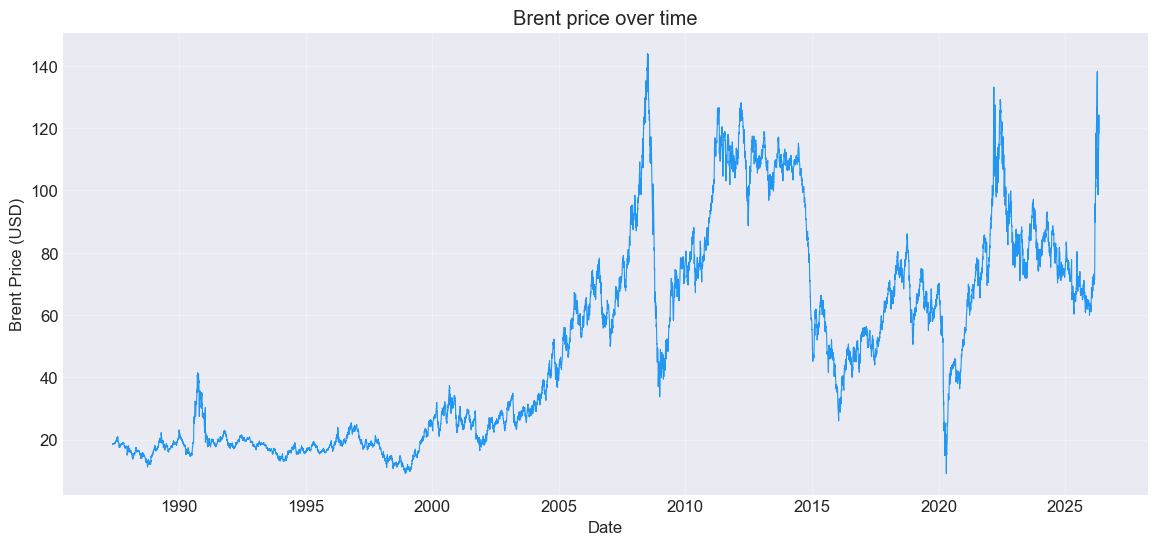

In [44]:
eje_x = brent['date']
eje_y = brent['price_usd']

plt.figure(figsize=(14, 6))
plt.plot(eje_x, eje_y, color='#2196F3', linewidth=0.8)
plt.title('Brent price over time')
plt.xlabel('Date')
plt.ylabel('Brent Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# Carga del precio WTI
# Los archivos de la EIA tienen 2 filas de cabecera que hay que saltar

wti = pd.read_csv('../data/raw/wti_daily.csv', 
                    skiprows=3,
                    names=['date', 'price_usd'], sep=';', decimal=',')

meses_es_en = {
    'ene': 'jan', 'feb': 'feb', 'mar': 'mar', 'abr': 'apr',
    'may': 'may', 'jun': 'jun', 'jul': 'jul', 'ago': 'aug',
    'sep': 'sep', 'oct': 'oct', 'nov': 'nov', 'dic': 'dec'
}

for es, en in meses_es_en.items():
    wti['date'] = wti['date'].str.replace(es, en, case=False)

# Limpieza básica
wti['date'] = pd.to_datetime(wti['date'], format='%b %d, %Y')
wti = wti.dropna()
wti = wti.sort_values('date').reset_index(drop=True)

print(f"Registros totales: {len(wti)}")
print(f"Período: {wti['date'].min().date()} a {wti['date'].max().date()}")
print(f"\nPrimeras filas:")
print(wti.head())
print(f"\nÚltimas filas:")
print(wti.tail())
print(f"\nEstadísticas básicas:")
print(wti['price_usd'].describe())

Registros totales: 10153
Período: 1986-01-02 a 2026-05-04

Primeras filas:
        date  price_usd
0 1986-01-02      25.56
1 1986-01-03      26.00
2 1986-01-06      26.53
3 1986-01-07      25.85
4 1986-01-08      25.87

Últimas filas:
            date  price_usd
10148 2026-04-28     103.45
10149 2026-04-29     110.47
10150 2026-04-30     108.64
10151 2026-05-01     105.38
10152 2026-05-04     109.76

Estadísticas básicas:
count   10153.00
mean       48.32
std        29.50
min       -36.98
25%        20.33
50%        43.04
75%        71.30
max       145.31
Name: price_usd, dtype: float64


In [46]:
merged_brent_wti = brent.merge(wti, on='date', suffixes=('_brent', '_wti'))
merged_brent_wti['spread'] = merged_brent_wti['price_usd_brent'] - merged_brent_wti['price_usd_wti']
merged_brent_wti.describe()

,date,price_usd_brent,price_usd_wti,spread
count,9708,9708.00,9708.00,9708.00
mean,2006-10-14 21:43:14.313967,51.17,49.48,1.69
min,1987-05-20 00:00:00,9.10,-36.98,-22.18
25%,1997-01-06 18:00:00,19.51,20.97,-1.61
50%,2006-10-24 12:00:00,46.04,45.75,-0.66
75%,2016-06-29 06:00:00,74.81,71.97,3.69
max,2026-05-01 00:00:00,143.95,145.31,54.34
std,NaN,32.80,29.34,5.40


In [47]:
max_date = merged_brent_wti.loc[merged_brent_wti['spread'].idxmax()]
min_date = merged_brent_wti.loc[merged_brent_wti['spread'].idxmin()]
print(min_date)

date               2008-09-22 00:00:00
price_usd_brent                 100.43
price_usd_wti                   122.61
spread                          -22.18
Name: 5330, dtype: object


In [48]:
merged_brent_wti.nlargest(10, 'spread')

,date,price_usd_brent,price_usd_wti,spread
8226,2020-04-20,17.36,-36.98,54.34
6085,2011-09-23,109.17,79.58,29.59
6071,2011-09-02,115.92,86.45,29.47
6074,2011-09-08,117.99,89.05,28.94
6084,2011-09-22,109.21,80.29,28.92
6083,2011-09-21,114.26,85.77,28.49
6099,2011-10-13,112.45,83.96,28.49
6080,2011-09-16,116.26,87.96,28.30
6073,2011-09-07,117.50,89.34,28.16
6086,2011-09-26,107.90,79.97,27.93


In [49]:
merged_brent_wti.nsmallest(10, 'spread')

,date,price_usd_brent,price_usd_wti,spread
5330,2008-09-22,100.43,122.61,-22.18
5327,2008-09-17,86.09,97.39,-11.30
5333,2008-09-25,100.45,111.54,-11.09
5329,2008-09-19,93.46,104.05,-10.59
5400,2008-12-31,35.82,44.60,-8.78
5342,2008-10-08,80.77,88.94,-8.17
5359,2008-10-31,60.00,68.10,-8.10
4371,2004-11-15,39.32,46.95,-7.63
5361,2008-11-04,62.78,70.41,-7.63
5347,2008-10-15,66.86,74.38,-7.52


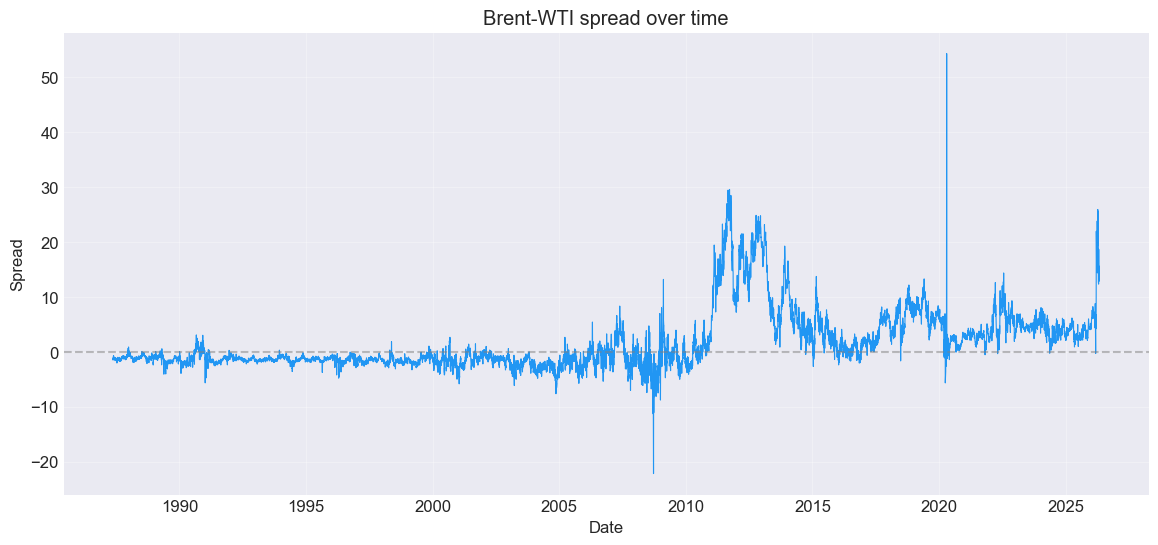

In [50]:
plt.figure(figsize=(14, 6))
plt.plot(merged_brent_wti['date'], merged_brent_wti['spread'], color='#2196F3', linewidth=0.8)
plt.title('Brent-WTI spread over time')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [51]:
eia_month = pd.read_csv('../data/raw/INT-Export-06-02-2026_12-44-43.csv',skiprows=1)
eia_month = eia_month.drop(0)
eia_month = eia_month.drop('API',axis=1)
eia_month = eia_month.rename(columns={'Unnamed: 1':'country'})
eia_month.head()

eia_month_long = eia_month.melt(id_vars='country',var_name='date_str', value_name='production_kbd')
eia_month_long['date_str'] = pd.to_datetime(eia_month_long['date_str'], format='%b %Y')
eia_month_long['production_kbd'] = pd.to_numeric(eia_month_long['production_kbd'], errors='coerce')

eia_dates = eia_month_long.groupby('country')['date_str'].min()
eia_dates.head(20)

country
Brazil                 1973-01-01
Canada                 1973-01-01
China                  1973-01-01
Iran                   1973-01-01
Iraq                   1973-01-01
Kuwait                 1973-01-01
Mexico                 1973-01-01
Russia                 1973-01-01
Saudi Arabia           1973-01-01
United Arab Emirates   1973-01-01
United States          1973-01-01
Venezuela              1973-01-01
Name: date_str, dtype: datetime64[us]

In [52]:
non_nan = eia_month_long[eia_month_long['production_kbd'].notna()]
grouped_non_nan = non_nan.groupby('country')['date_str'].min()
grouped_non_nan.head(20)

country
Brazil                 1984-01-01
Canada                 1973-01-01
China                  1973-01-01
Iran                   1973-01-01
Iraq                   1973-01-01
Kuwait                 1973-01-01
Mexico                 1973-01-01
Russia                 1992-01-01
Saudi Arabia           1973-01-01
United Arab Emirates   1973-01-01
United States          1973-01-01
Venezuela              1973-01-01
Name: date_str, dtype: datetime64[us]

La producción de Rusia empieza en 1992 tras la disolución de la URSS.

Pasamos a unir el spread de Brent y WTI con la procucción, pero para ello debemos tener el mismo formato temporal

In [53]:
merged_brent_wti_month = merged_brent_wti.resample('ME',on='date').mean()

In [54]:
merged_brent_wti_month.head()

,price_usd_brent,price_usd_wti,spread
date,,,
1987-05-31,18.58,19.54,-0.96
1987-06-30,18.86,20.07,-1.21
1987-07-31,19.86,21.34,-1.49
1987-08-31,18.98,20.31,-1.33
1987-09-30,18.31,19.53,-1.22


Como el spread tiene como fecha el último día del mes y la producción el primero, creamos en ambos frames una columna Period

In [55]:
merged_brent_wti_month['period']=merged_brent_wti_month.index.to_period('M')
merged_brent_wti_month.head()

,price_usd_brent,price_usd_wti,spread,period
date,,,,
1987-05-31,18.58,19.54,-0.96,1987-05
1987-06-30,18.86,20.07,-1.21,1987-06
1987-07-31,19.86,21.34,-1.49,1987-07
1987-08-31,18.98,20.31,-1.33,1987-08
1987-09-30,18.31,19.53,-1.22,1987-09


In [56]:
production = eia_month_long
production['period'] = production['date_str'].dt.to_period('M')
production.head(20)

,country,date_str,production_kbd,period
0,Brazil,1973-01-01,NaN,1973-01
1,Canada,1973-01-01,1778.00,1973-01
2,China,1973-01-01,1012.00,1973-01
3,Iran,1973-01-01,5808.00,1973-01
4,Iraq,1973-01-01,1527.00,1973-01
5,Kuwait,1973-01-01,3768.00,1973-01
6,Mexico,1973-01-01,453.00,1973-01
7,Russia,1973-01-01,NaN,1973-01
8,Saudi Arabia,1973-01-01,6876.00,1973-01
9,United Arab Emirates,1973-01-01,1416.00,1973-01


In [57]:
production['country'] = production['country'].str.strip()
production_usa = production[production['country'] == 'United States']
production_usa.head()
merged_spread_prod = merged_brent_wti_month.merge(production_usa, on='period')
merged_spread_prod.head(20)

,price_usd_brent,price_usd_wti,spread,period,country,date_str,production_kbd
0,18.58,19.54,-0.96,1987-05,United States,1987-05-01,8336.00
1,18.86,20.07,-1.21,1987-06,United States,1987-06-01,8279.00
2,19.86,21.34,-1.49,1987-07,United States,1987-07-01,8251.00
3,18.98,20.31,-1.33,1987-08,United States,1987-08-01,8210.00
4,18.31,19.53,-1.22,1987-09,United States,1987-09-01,8205.00
5,18.76,19.86,-1.10,1987-10,United States,1987-10-01,8364.00
6,17.78,18.85,-1.07,1987-11,United States,1987-11-01,8397.00
7,17.05,17.27,-0.22,1987-12,United States,1987-12-01,8318.00
8,16.75,17.13,-0.38,1988-01,United States,1988-01-01,8250.00
9,15.73,16.80,-1.07,1988-02,United States,1988-02-01,8374.00


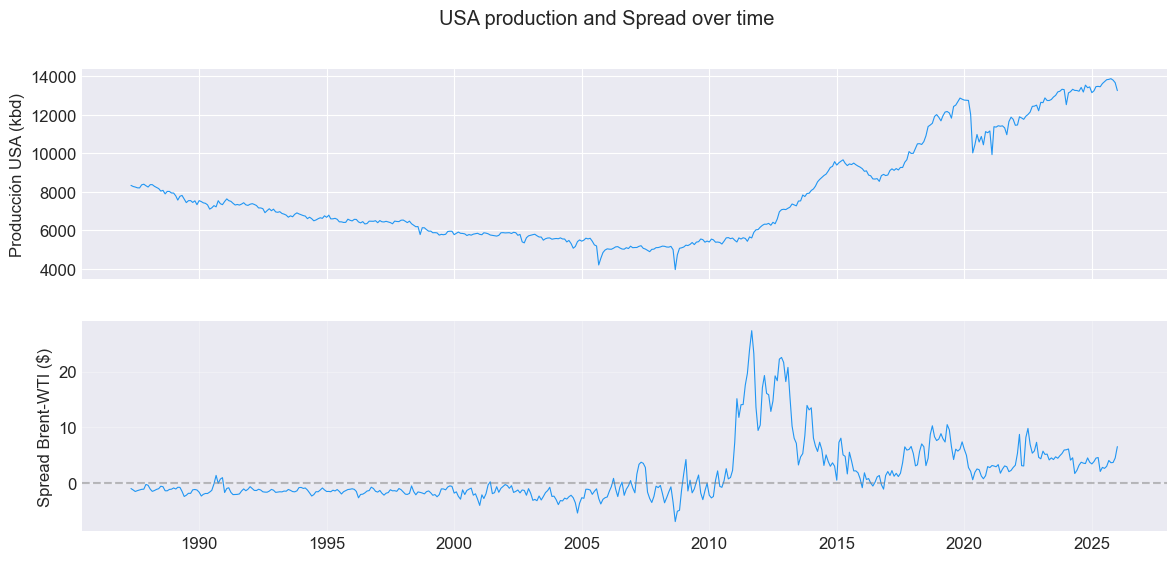

In [58]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6))
ax1.plot(merged_spread_prod['date_str'], merged_spread_prod['production_kbd'], color='#2196F3', linewidth=0.8)
ax2.plot(merged_spread_prod['date_str'], merged_spread_prod['spread'], color='#2196F3', linewidth=0.8)
ax1.set_ylabel('Producción USA (kbd)')
ax2.set_ylabel('Spread Brent-WTI ($)')
plt.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('USA production and Spread over time')
plt.show()

El cambio de régimen del spread Brent-WTI a partir de 2011 coincide temporalmente con el despegue de la producción de crudo de EEUU (de ~5.000 a ~13.000 kbd vía shale). El mecanismo: el exceso de crudo americano, atrapado por la prohibición de exportación vigente hasta 2015 y la capacidad logística limitada de Cushing, deprimió el WTI frente al Brent. La moderación parcial del spread desde 2016 es consistente con el levantamiento de dicha prohibición. La producción de EEUU es, por tanto, una variable explicativa de primer orden del spread.

Ahora cargamos los datos semanales de Cushing, lo que nos peritirá entender el efecto Shale de 2011 en adelante. Inventarios comerciales de Cushing, excluyendo la Reserva Estratégica (SPR), por ser estos los relevantes para la formación del precio del WTI.

In [59]:
cushing_weekly = pd.read_csv('../data/raw/Weekly_Cushing_OK_Ending_Stocks_excluding_SPR_of_Crude_Oil.csv', skiprows=4)
cushing_weekly = cushing_weekly.rename(columns={'Week of':'date', 'Weekly Cushing OK Ending Stocks excluding SPR of Crude Oil  Thousand Barrels':'cushing_stocks_kb'})
cushing_weekly['date'] = pd.to_datetime(cushing_weekly['date'])
cushing_monthly = cushing_weekly.resample('ME', on='date').mean().reset_index()
cushing_monthly.head()

,date,cushing_stocks_kb
0,2004-04-30,12456.25
1,2004-05-31,14834.50
2,2004-06-30,14383.50
3,2004-07-31,15884.00
4,2004-08-31,14472.25


In [60]:
cushing_monthly['period'] = cushing_monthly['date'].dt.to_period('M')
merged_cushing_spread = cushing_monthly.merge(merged_brent_wti_month, on='period')

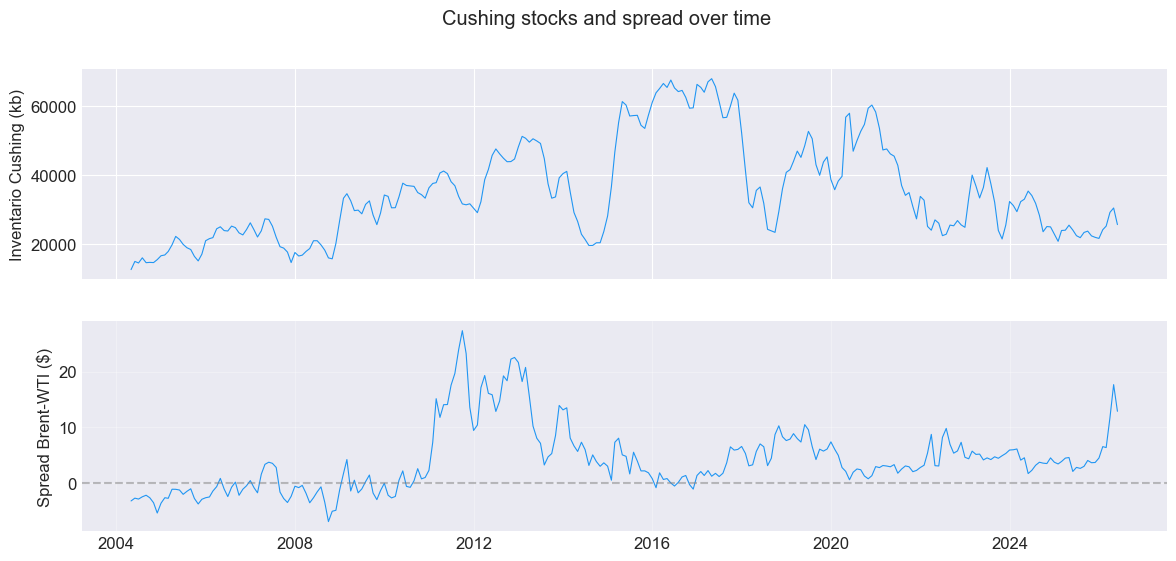

In [61]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6))
ax1.plot(merged_cushing_spread['date'], merged_cushing_spread['cushing_stocks_kb'], color='#2196F3', linewidth=0.8)
ax2.plot(merged_cushing_spread['date'], merged_cushing_spread['spread'], color='#2196F3', linewidth=0.8)
ax1.set_ylabel('Inventario Cushing (kb)')
ax2.set_ylabel('Spread Brent-WTI ($)')
plt.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('Cushing stocks and spread over time')
plt.show()

La relación entre inventarios de Cushing y spread Brent-WTI no es estacionaria. Es fuerte en 2011-2014 (Cushing saturado deprime el WTI con el spread en máximos), pero se desacopla a partir de 2016: niveles récord de inventario en Cushing coexisten con spreads moderados. La causa probable es el levantamiento de la prohibición de exportación de crudo de EEUU (dic. 2015), que convirtió Cushing de cuello de botella sin salida en un nodo con válvula de escape hacia los puertos de exportación. Implicación para el modelado: la relación inventario-spread depende del régimen institucional y no puede modelarse como homogénea en toda la serie.

In [62]:
import sys
sys.path.append('..')
from src.data.loaders import load_prices, load_production, load_cushing
prices = load_prices()
production = load_production()
cushing = load_cushing()

In [63]:
import sqlite3

conn = sqlite3.connect('../data/oganalytics.db')
print(conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall())
conn.close()

[('prices',), ('production',), ('inventories',)]


In [64]:
#Comparamos el spread mensual con el que obtenemos en SQL para comprobar si la base de datos creada en SQL es correcta
merged_brent_wti_month['spread'].mean()

np.float64(1.7200427560260572)

In [65]:
from sklearn.ensemble import IsolationForest

merged_brent_wti_month_IsolationForest = merged_brent_wti_month.reset_index()
X = merged_brent_wti_month_IsolationForest[['spread']]
clf = IsolationForest(max_samples=100, random_state=42, contamination=20/469)
clf.fit(X)
merged_brent_wti_month_IsolationForest['prediction'] = clf.predict(X)

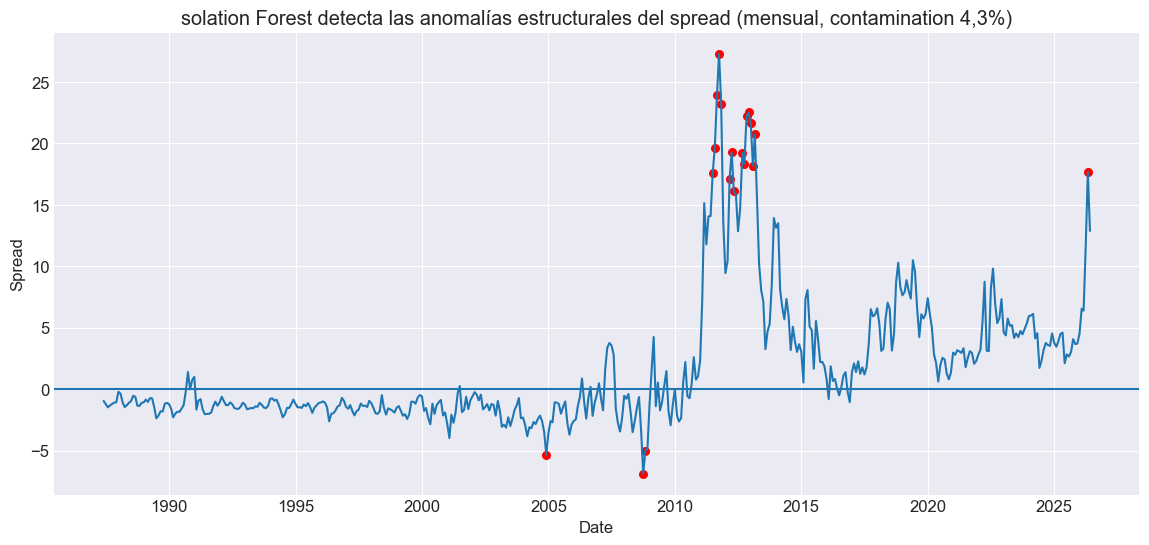

In [66]:
plt.plot(merged_brent_wti_month_IsolationForest['date'], merged_brent_wti_month_IsolationForest['spread'])
anomalies = merged_brent_wti_month_IsolationForest[merged_brent_wti_month_IsolationForest['prediction'] == -1]
plt.scatter(anomalies['date'], anomalies['spread'], color='red', s=30, label='Anomalías detectadas')
plt.title('solation Forest detecta las anomalías estructurales del spread (mensual, contamination 4,3%)')
plt.axhline(0)
plt.xlabel('Date')
plt.ylabel('Spread')
plt.show()

Es importante recalcar que la granularidad de la resolución mensual no permite ver el gran aumento del spread que se produjo en un solo día de 2020, ya que esta resolución solo permite ver desviaciones sostenidas. Esta es la resolución relevante para este poryecto.

In [67]:
anomalies[anomalies['date'] < '2006'] 

,date,price_usd_brent,price_usd_wti,spread,period,prediction
210,2004-11-30,43.12,48.47,-5.35,2004-11,-1


In [68]:
merged_brent_wti_month['next_month_spread'] = merged_brent_wti_month['spread'].shift(-1)
merged_brent_wti_month

,price_usd_brent,price_usd_wti,spread,period,next_month_spread
date,,,,,
1987-05-31,18.58,19.54,-0.96,1987-05,-1.21
1987-06-30,18.86,20.07,-1.21,1987-06,-1.49
1987-07-31,19.86,21.34,-1.49,1987-07,-1.33
1987-08-31,18.98,20.31,-1.33,1987-08,-1.22
1987-09-30,18.31,19.53,-1.22,1987-09,-1.10
...,...,...,...,...,...
2026-01-31,66.59,60.04,6.55,2026-01,6.38
2026-02-28,70.89,64.51,6.38,2026-02,11.75
2026-03-31,103.13,91.38,11.75,2026-03,17.66


Hemos añadido la columna del feature del sread del mes siguiente (t+1), ahora hay que añadir columnas de spread de meses anteriores (t-1), (t-2), (t-3) ... teniendo en cuenta que mas columnas capturan más períodos temporales pero sobre una serie de solo 469 observaciones, y con pocas observaciones por feature el sobreajuste acecha.

In [69]:
for lag in (3, 6, 12):
    merged_brent_wti_month[f'spread_lag_{lag}'] = merged_brent_wti_month['spread'].shift(lag)

merged_brent_wti_month

,price_usd_brent,price_usd_wti,spread,period,next_month_spread,spread_lag_3,spread_lag_6,spread_lag_12
date,,,,,,,,
1987-05-31,18.58,19.54,-0.96,1987-05,-1.21,NaN,NaN,NaN
1987-06-30,18.86,20.07,-1.21,1987-06,-1.49,NaN,NaN,NaN
1987-07-31,19.86,21.34,-1.49,1987-07,-1.33,NaN,NaN,NaN
1987-08-31,18.98,20.31,-1.33,1987-08,-1.22,-0.96,NaN,NaN
1987-09-30,18.31,19.53,-1.22,1987-09,-1.10,-1.21,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-01-31,66.59,60.04,6.55,2026-01,6.38,3.67,2.65,3.45
2026-02-28,70.89,64.51,6.38,2026-02,11.75,3.71,3.02,3.89
2026-03-31,103.13,91.38,11.75,2026-03,17.66,4.51,4.07,4.49


Si hacemos un Rolling(3) estamos mirando a t, t-1 y t-2. Aquí no hay leackage porque t ya es conocido, teniendo en cuenta que nuestro objetivo es t+1.

In [70]:
for ventana in (3, 6, 12):
    merged_brent_wti_month[f'spread_ma_{ventana}'] = merged_brent_wti_month['spread'].rolling(ventana).mean()
    merged_brent_wti_month[f'spread_std_{ventana}'] = merged_brent_wti_month['spread'].rolling(ventana).std()
merged_brent_wti_month

,price_usd_brent,price_usd_wti,spread,period,next_month_spread,spread_lag_3,spread_lag_6,spread_lag_12,spread_ma_3,spread_std_3,spread_ma_6,spread_std_6,spread_ma_12,spread_std_12
date,,,,,,,,,,,,,,
1987-05-31,18.58,19.54,-0.96,1987-05,-1.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987-06-30,18.86,20.07,-1.21,1987-06,-1.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987-07-31,19.86,21.34,-1.49,1987-07,-1.33,NaN,NaN,NaN,-1.22,0.26,NaN,NaN,NaN,NaN
1987-08-31,18.98,20.31,-1.33,1987-08,-1.22,-0.96,NaN,NaN,-1.34,0.14,NaN,NaN,NaN,NaN
1987-09-30,18.31,19.53,-1.22,1987-09,-1.10,-1.21,NaN,NaN,-1.34,0.13,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-31,66.59,60.04,6.55,2026-01,6.38,3.67,2.65,3.45,4.92,1.46,4.25,1.23,3.84,1.17
2026-02-28,70.89,64.51,6.38,2026-02,11.75,3.71,3.02,3.89,5.81,1.13,4.81,1.32,4.05,1.38
2026-03-31,103.13,91.38,11.75,2026-03,17.66,4.51,4.07,4.49,8.23,3.05,6.09,3.05,4.65,2.62


El Spread es Mean-Reverting, lo que significa que el spread Brent-WTI tiende a volver hacia su nivel habitual. Cuando se aleja mucho, fuerzas de arbitraje lo traen de vuelta. Si el Brent está mucho más caro que el WTI, a alguien le compensa comprar WTI barato, pagar el transporte y venderlo como Brent caro. Ese arbitraje cierra la diferencia. Por eso el spread no se va a infinito: gravita hacia el coste de arbitraje.
Calculando el spread_actual - media_movil_6_meses podemos saber cómo de lejos está el spread de su nivel normal. El signo y la magnitud de esa resta son una señal directa de en qué dirección debería moverse el spread si la reversión funciona. Eso es información predictiva concentrada en una sola columna. 

In [71]:
merged_brent_wti_month['spread_dev_ma6'] = merged_brent_wti_month['spread'] - merged_brent_wti_month['spread_ma_6']
merged_brent_wti_month

,price_usd_brent,price_usd_wti,spread,period,next_month_spread,spread_lag_3,spread_lag_6,spread_lag_12,spread_ma_3,spread_std_3,spread_ma_6,spread_std_6,spread_ma_12,spread_std_12,spread_dev_ma6
date,,,,,,,,,,,,,,,
1987-05-31,18.58,19.54,-0.96,1987-05,-1.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987-06-30,18.86,20.07,-1.21,1987-06,-1.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987-07-31,19.86,21.34,-1.49,1987-07,-1.33,NaN,NaN,NaN,-1.22,0.26,NaN,NaN,NaN,NaN,NaN
1987-08-31,18.98,20.31,-1.33,1987-08,-1.22,-0.96,NaN,NaN,-1.34,0.14,NaN,NaN,NaN,NaN,NaN
1987-09-30,18.31,19.53,-1.22,1987-09,-1.10,-1.21,NaN,NaN,-1.34,0.13,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-31,66.59,60.04,6.55,2026-01,6.38,3.67,2.65,3.45,4.92,1.46,4.25,1.23,3.84,1.17,2.30
2026-02-28,70.89,64.51,6.38,2026-02,11.75,3.71,3.02,3.89,5.81,1.13,4.81,1.32,4.05,1.38,1.57
2026-03-31,103.13,91.38,11.75,2026-03,17.66,4.51,4.07,4.49,8.23,3.05,6.09,3.05,4.65,2.62,5.66


Ahora hay que hacer le merge con producción y con cushing. Hay que tener en cuenta que la EIA publica los datos de producción con unos meses de antelación, por lo que habrá que añadir un lag a los datos para evitar un data leakage. Los datos de cushing suelen publicarse unos días más tarde, con lo que un lag de 1 mes sería realista.

Decisión: exclusión de los inventarios de Cushing del conjunto de features principal

La serie de inventarios de Cushing comienza en abril de 2004, mientras que la serie del spread arranca en mayo de 1987. Incorporar Cushing mediante un inner join reduciría el conjunto de entrenamiento de 469 a aproximadamente 260 observaciones mensuales, una pérdida del 45% de los datos disponibles.

Ese coste no está justificado por el valor esperado de la variable. El análisis de la Fase 1 mostró que la relación entre los inventarios de Cushing y el spread no es estacionaria: es fuerte durante 2011-2014, cuando la saturación del punto de entrega del WTI deprimía su precio frente al Brent, pero se desacopla a partir de 2016, cuando el levantamiento de la prohibición de exportación de crudo estadounidense convirtió Cushing de cuello de botella sin salida en un nodo con evacuación hacia los puertos del Golfo. Sacrificar casi la mitad de las observaciones a cambio de una variable cuya capacidad explicativa se limita a un tramo concreto de la serie empeora la relación observaciones/features sin una ganancia predictiva clara.

En consecuencia, el modelo principal se entrena sobre la serie larga (1987-2026) con features derivadas del propio spread y de la producción de crudo de EE. UU. Los inventarios de Cushing se reservan para un análisis secundario sobre el subperiodo 2004-2026, donde podrá evaluarse empíricamente si aportan capacidad predictiva y, en particular, si esa aportación se concentra en el régimen 2011-2015 como sugiere el análisis exploratorio.

In [72]:
production = load_production()
production_usa = production[production['country'] == 'United States']

usa_features = merged_brent_wti_month.merge(production_usa, how='inner', on='period')
usa_features['production_kbd'] = usa_features['production_kbd'].shift(3)
usa_features = usa_features.dropna()
usa_features = usa_features.rename(columns={'date_str': 'date'})
usa_features = usa_features.set_index('date')
usa_features

,price_usd_brent,price_usd_wti,spread,period,next_month_spread,spread_lag_3,spread_lag_6,spread_lag_12,spread_ma_3,spread_std_3,spread_ma_6,spread_std_6,spread_ma_12,spread_std_12,spread_dev_ma6,country,production_kbd
date,,,,,,,,,,,,,,,,,
1988-05-01,16.31,17.42,-1.11,1988-05,-0.98,-1.07,-1.07,-0.96,-1.30,0.18,-0.93,0.51,-1.08,0.39,-0.18,United States,8374.00
1988-06-01,15.54,16.53,-0.98,1988-06,-0.55,-1.47,-0.22,-1.21,-1.14,0.17,-1.05,0.37,-1.06,0.39,0.07,United States,8374.00
1988-07-01,14.95,15.50,-0.55,1988-07,-0.63,-1.31,-0.38,-1.49,-0.88,0.30,-1.08,0.32,-0.98,0.39,0.53,United States,8288.00
1988-08-01,14.89,15.52,-0.63,1988-08,-1.36,-1.11,-1.07,-1.33,-0.72,0.23,-1.01,0.37,-0.93,0.39,0.38,United States,8229.00
1988-09-01,13.18,14.54,-1.36,1988-09,-1.36,-0.98,-1.47,-1.22,-0.84,0.45,-0.99,0.34,-0.94,0.40,-0.37,United States,8170.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,68.03,63.96,4.07,2025-09,3.67,2.83,4.49,3.59,3.25,0.74,3.21,0.94,3.58,0.80,0.86,United States,13610.48
2025-10-01,64.56,60.89,3.67,2025-10,3.71,2.65,4.60,3.52,3.59,0.53,3.06,0.71,3.59,0.80,0.61,United States,13707.28
2025-11-01,63.77,60.06,3.71,2025-11,4.51,3.02,2.10,4.53,3.82,0.22,3.32,0.57,3.52,0.75,0.39,United States,13810.12


Para las features no seleccionamos el objetivo (next_month_spread), los identificadores (period, date), y el texto constante (country). Seleccionamos price_usd_brent y price_usd_wti porque el nivel absoluto de precios puede importar (un spread de 5 dólares no significa lo mismo con el crudo a 20 que a 120).

In [73]:
y = usa_features['next_month_spread']
feature_cols = ['price_usd_brent', 'price_usd_wti', 'spread', 'spread_lag_3', 'spread_lag_6', 'spread_lag_12', 'spread_ma_3', 'spread_ma_6', 'spread_ma_12', 'spread_std_3', 'spread_std_6', 'spread_std_12', 'spread_dev_ma6', 'production_kbd']
X = usa_features[feature_cols]

Una vez tenemos las features, vamos a hacer el Baseline

In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

spread = usa_features['spread']
RMSE = np.sqrt(mean_squared_error(spread, y))
MAE = mean_absolute_error(spread, y)

print(RMSE)
print(MAE)

1.6624892427348
1.0658273252592287


MAE promedia los errores tal cual; RMSE los eleva al cuadrado antes de promediar, así que los errores grandes pesan desproporcionadamente. Cuando RMSE >> MAE, significa que la distribución de errores tiene cola: la mayoría de los meses el naive falla poco (por eso el MAE es 1.07), pero hay unos pocos meses donde falla mucho, y esos son los que inflan el RMSE.

Septiembre 2008, la entrada en el régimen de 2011, marzo-abril de 2026 (donde el spread saltó de 6 a 11 a 17). En esos meses, asumir "mañana será como hoy" falla estrepitosamente.

Pasamos a la validación. Sabemos que no podemos usar un test/train split porque son series temporales, por lo que necesitamos un TimeSeriesSplit

TimeSeriesSplit es interesnte porque:
1) El train siempre empieza en el mes 1 y crece. Se llama "ventana expansiva": el modelo va acumulando historia, igual que en la vida real.
2) El test es siempre posterior al train. Nunca al revés. Eso es lo que elimina el leakage temporal.
3) Los primeros meses nunca se usan como test. Necesitas un mínimo de historia para entrenar el primer modelo.

Al final tienes 5 evaluaciones (una por split), y promedias las métricas. Pero ojo: como cada split evalúa un periodo distinto de tu serie, la variación entre splits es información valiosa, no ruido a promediar.

Esto es interesante porque:
1) Los primeros splits validan sobre los años 90 y 2000: régimen pre-shale, spread plano cerca de cero. Fácil de predecir.
2) Los splits centrales pillan 2008-2013: el squeeze, el cambio de régimen, la meseta. Difícil.
3) El último split valida sobre ~2020-2026: incluye el COVID y el pico de 2026.

Esto permitirá ver si lo que predije (los errores más grandes se producirán en los cambios de régimen) se cumple.

Hay que decidir:
1) Número de splits. Más splits = más evaluaciones pero cada test más pequeño, más granularidad temporal en el análisis.
2) Test_size. Se puede usar para decidir qué longitud tienen los tests.
3) Gap. Deja un hueco entre el train y el split. Puede ser útil para eliminar el solapamiento entre el final del train y el comienzo del test.

Se puede hacer de forma manual (con un bucle) o automatizado con cross_val_score(modelo, X, y, cv=tscv, scoring=...).

Cuando se entrena Ridge, el escalado debe ir dentro de cada split, ajustado solo con el train de ese split. Por eso se usa un Pipeline: encadena scaler + modelo y garantiza que el scaler se ajusta solo con train. Si escalas antes del bucle, con toda la serie, tienes leakage.

In [75]:
from sklearn.model_selection import TimeSeriesSplit

split = TimeSeriesSplit(n_splits=5, gap=3)

for train_index, test_index in split.split(X):
    print("TRAIN:", X.index[train_index[0]], "→", X.index[train_index[-1]])
    print("TEST: ", X.index[test_index[0]], "→", X.index[test_index[-1]])
    print()

TRAIN: 1988-05-01 00:00:00 → 1994-07-01 00:00:00
TEST:  1994-11-01 00:00:00 → 2001-01-01 00:00:00

TRAIN: 1988-05-01 00:00:00 → 2000-10-01 00:00:00
TEST:  2001-02-01 00:00:00 → 2007-04-01 00:00:00

TRAIN: 1988-05-01 00:00:00 → 2007-01-01 00:00:00
TEST:  2007-05-01 00:00:00 → 2013-07-01 00:00:00

TRAIN: 1988-05-01 00:00:00 → 2013-04-01 00:00:00
TEST:  2013-08-01 00:00:00 → 2019-10-01 00:00:00

TRAIN: 1988-05-01 00:00:00 → 2019-07-01 00:00:00
TEST:  2019-11-01 00:00:00 → 2026-01-01 00:00:00



El método split(X) devuelve, en cada vuelta, dos arrays de índices: las posiciones de las filas que van a train y las que van a test. Por eso el for recibe dos variables.
Split 1: 1994-2001 → régimen pre-shale, spread plano
Split 2: 2001-2007 → pre-shale, incluye tu anomalía de 2004
Split 3: 2007-2013 → el squeeze de 2008 Y el arranque del shale boom
Split 4: 2013-2019 → la salida del régimen alto, el fin de la prohibición de exportación (2015)
Split 5: 2019-2026 → COVID, Ucrania, el pico de 2026

La prediccion para el RMSE es:
Splits 1 y 2 (1994-2007): spread plano cerca de cero, poca variación. El naive debería ir muy bien ahí, y cualquier modelo también. RMSE bajo.
Split 3 (2007-2013): pilla el squeeze de 2008 y la explosión de 2011. Es el más difícil con diferencia.
Split 4 (2013-2019): la meseta cayendo y normalizándose. Difícil pero menos.
Split 5 (2019-2026): incluye COVID y el salto de 2026. Difícil al final.

In [87]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

import pandas as pd

resultados = []

for i, (train_index, test_index) in enumerate(split.split(X)):
    # Separar train y test con los índices del split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Baseline naive: predecir que el spread no cambia
    pred_naive = X_test['spread']
    
    # Regresión lineal
    modelo_lr = LinearRegression()
    modelo_lr.fit(X_train, y_train)
    pred_lr = modelo_lr.predict(X_test)

    # Ridge    
    modelo_ridge =  Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=100))])
    modelo_ridge.fit(X_train, y_train)
    pred_ridge = modelo_ridge.predict(X_test)

    # Gradient Boosting
    modelo_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    modelo_gb.fit(X_train, y_train)
    pred_gb = modelo_gb.predict(X_test)

    # XGBRegressor
    modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    modelo_xgb.fit(X_train, y_train)
    pred_xgb = modelo_xgb.predict(X_test)
    
    # Guardar métricas
    resultados.append({
        'split': i + 1,
        'periodo_test': f"{X.index[test_index[0]].date()} → {X.index[test_index[-1]].date()}",
        'rmse_naive': np.sqrt(mean_squared_error(y_test, pred_naive)),
        'mae_naive': mean_absolute_error(y_test, pred_naive),
        'rmse_lr': np.sqrt(mean_squared_error(y_test, pred_lr)),
        'mae_lr': mean_absolute_error(y_test, pred_lr),
        'rmse_ridge': np.sqrt(mean_squared_error(y_test, pred_ridge)),
        'mae_ridge': mean_absolute_error(y_test, pred_ridge),
        'rmse_gb': np.sqrt(mean_squared_error(y_test, pred_gb)),
        'mae_gb': mean_absolute_error(y_test, pred_gb),
        'rmse_xgb': np.sqrt(mean_squared_error(y_test, pred_xgb)),
        'mae_xgb': mean_absolute_error(y_test, pred_xgb),
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,split,periodo_test,rmse_naive,mae_naive,rmse_lr,mae_lr,rmse_ridge,mae_ridge,rmse_gb,mae_gb,rmse_xgb,mae_xgb
0,1,1994-11-01 → 2001-01-01,0.57,0.42,0.50,0.36,0.56,0.39,1.24,0.76,1.33,0.76
1,2,2001-02-01 → 2007-04-01,1.04,0.83,1.29,1.00,1.19,0.94,1.42,1.11,1.38,1.08
2,3,2007-05-01 → 2013-07-01,2.97,2.33,5.05,3.58,5.57,3.98,11.67,8.17,11.95,8.38
3,4,2013-08-01 → 2019-10-01,2.03,1.53,2.07,1.63,2.15,1.68,7.33,6.59,4.61,3.43
4,5,2019-11-01 → 2026-01-01,1.43,0.97,1.44,1.00,1.33,0.93,1.53,1.09,1.71,1.33


Con alpha mayores el rmse empeora, ya podemos descartar la hipótesis del sobreajuste con fundamento: si el problema fuera que los coeficientes se disparaban, penalizarlos más habría ayudado. Ha pasado lo contrario. Al encoger los coeficientes agresivamente, el modelo pierde capacidad de ajuste sin ganar nada en generalización. Eso apunta a que el modelo lineal no estaba sobreajustando; estaba subajustando ya de partida para lo que necesita predecir.

O dicho de otro modo: el problema no es que el modelo aprendiera demasiado del train, sino que lo que aprendió del train no aplica al test. Ninguna regularización arregla eso, porque no es un problema de complejidad del modelo, es que los datos de entrenamiento describen un mundo distinto al de evaluación.

La selección de alpha se realizó de forma exploratoria; una implementación rigurosa requeriría validación anidada dentro de cada partición de entrenamiento.

GradientBoosting  XGB tienen RMSE y MAEs tan altos porque los árboles no extrapolan: nunca predicen fuera del rango visto. Entrenados hasta 2007, su máximo conocido ronda el +2. Así que en 2011, con el spread real en +25, predicen algo cercano a +2 y se equivocan por ~23. El naive, en cambio, "arrastra" el nivel actual y falla mucho menos.

Eso descarta también la hipótesis de la no linealidad: si el problema fuera la forma de la relación, los árboles (que capturan no linealidades) habrían mejorado. Han empeorado. Queda confirmado que el problema es el cambio de régimen, no la especificación del modelo. Ningún tipo de modelo, lineal o no, puede predecir un nivel que no existe en sus datos de entrenamiento.

Ningún modelo bate al naive de forma consistente. La LR gana solo en el split 1; Ridge en el 2 y el 5 por márgenes mínimos; los árboles pierden en todos, catastróficamente en el 3 y el 4. Según el criterio que tú mismo definiste, la conclusión es la que tu documento ya contemplaba: con estas features, el spread mensual no contiene señal explotable más allá de la persistencia.

El split 3 es e que presenta mayores errores, por culpa del cambio de régimen. El modelo no puede aprenderlo porque solo ocurre dos veces en cuarenta años. No hay ejemplos suficientes de transiciones para que ningún algoritmo generalice sobre ellas. La causa se conoce; lo que falta son observaciones. Esa formulación es más fuerte y conecta con tu Fase 1.

En el split 4 (2013-2019) el GB da 7.33 mientras que XGBoost da 4.61, una diferencia enorme entre dos modelos de la misma familia con los mismos hiperparámetros nominales. Eso sugiere sensibilidad a los detalles de implementación (XGBoost tiene regularización incorporada por defecto, GB de sklearn no). Vale la pena mencionarlo: dos implementaciones de "gradient boosting" no son intercambiables.

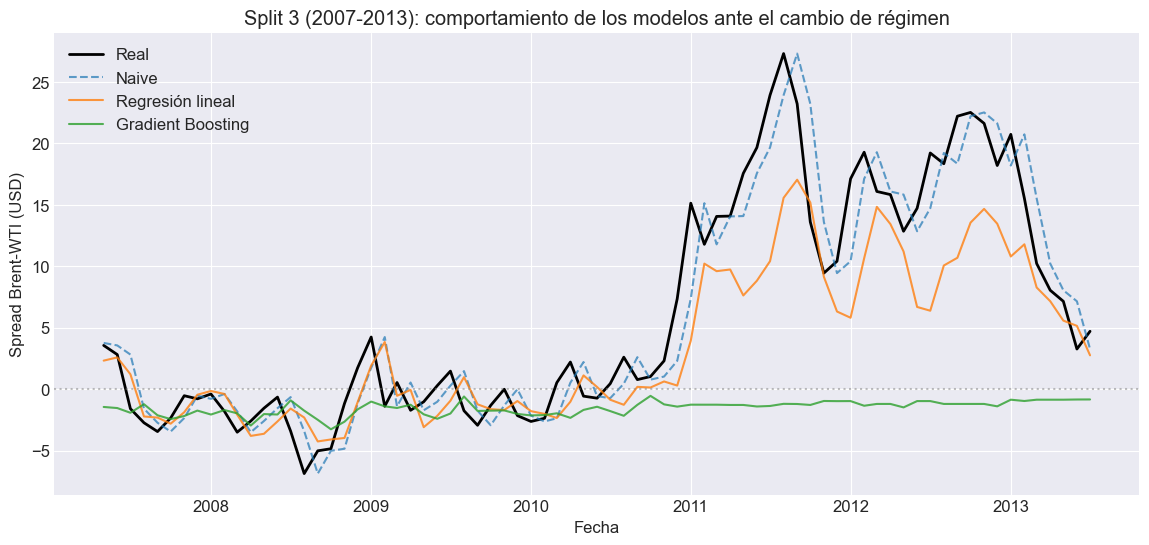

In [88]:
# Recuperar el split 3 (índice 2, porque enumerate empieza en 0)
splits = list(split.split(X))
train_index, test_index = splits[2]

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Reentrenar los modelos sobre ese split
pred_naive = X_test['spread']

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

modelo_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
modelo_gb.fit(X_train, y_train)
pred_gb = modelo_gb.predict(X_test)

# Gráfica
fechas = X.index[test_index]

plt.figure(figsize=(14, 6))
plt.plot(fechas, y_test, label='Real', color='black', linewidth=2)
plt.plot(fechas, pred_naive, label='Naive', linestyle='--', alpha=0.7)
plt.plot(fechas, pred_lr, label='Regresión lineal', alpha=0.8)
plt.plot(fechas, pred_gb, label='Gradient Boosting', alpha=0.8)

plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.title('Split 3 (2007-2013): comportamiento de los modelos ante el cambio de régimen')
plt.xlabel('Fecha')
plt.ylabel('Spread Brent-WTI (USD)')
plt.legend()
plt.show()

El split 3 ilustra por qué ningún modelo supera al baseline durante el cambio de régimen. El Gradient Boosting, entrenado con datos donde el spread nunca superó los 2 USD, permanece plano en torno a -1 mientras el valor real alcanza 27: los modelos basados en árboles no extrapolan fuera del rango observado en entrenamiento. La regresión lineal sí extrapola y reproduce la forma del movimiento, pero infraestima sistemáticamente su magnitud, al aplicar coeficientes calibrados sobre un régimen de variación de ±3 USD a otro de ±25. El baseline naive, que se limita a persistir el valor actual, resulta el más preciso de los tres pese a su simplicidad: llega con un mes de retraso a cada giro pero nunca se desvía estructuralmente. La conclusión no es que los modelos estén mal especificados, sino que el cambio de régimen de 2011 es un evento sin precedentes en los datos de entrenamiento, y ningún algoritmo puede aprender de transiciones que solo ocurren dos veces en cuarenta años.